In [1]:
# help for the project https://medium.com/@christopherha7/telco-customer-churn-analysis-80475aa6c7f8

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import FixedLocator
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("telecom_customer_churn.csv")

In [4]:
# 1. Isolate the population (Exclude Joined)
analysis_df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()

# 2. Corrected Normalised Value Factor (NVF)
norm_df = analysis_df[['Customer ID', 'Monthly Charge', 'Tenure in Months', 'Number of Referrals', 'Customer Status']].copy()
norm_df.columns = ['Customer ID', 'MonthlyCharges', 'Tenure', 'Referrals', 'Customer Status']

def min_max_scale(column):
    return (column - column.min()) / (column.max() - column.min())

norm_df['Monthly_norm'] = min_max_scale(norm_df['MonthlyCharges'])
norm_df['Tenure_norm'] = min_max_scale(norm_df['Tenure'])
norm_df['Referrals_norm'] = min_max_scale(norm_df['Referrals'] + 1)

# Calculate NVF (Y-Axis)
norm_df['NVF'] = (norm_df['Monthly_norm'] + norm_df['Tenure_norm'] + norm_df['Referrals_norm']) / 3

# 3. Corrected Normalised Churn Risk Factor (NCRF)
risk_columns = [
    'Contract', 'Online Security', 'Premium Tech Support', 
    'Paperless Billing', 'Payment Method', 'Internet Type',
    'Online Backup', 'Device Protection Plan', 'Offer', 
    'Streaming Music', 'Streaming TV'
]
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

analysis_df[service_cols] = analysis_df[service_cols].fillna('None')
global_churn_rate = analysis_df['Customer Status'].value_counts(normalize=True)['Churned']

all_weights = {}
for col in risk_columns:
    ct = pd.crosstab(analysis_df[col], analysis_df['Customer Status'], normalize='index')
    all_weights[col] = (ct['Churned'] - global_churn_rate).to_dict()

analysis_df['Raw_Risk_Score'] = 0
for col in risk_columns:
    analysis_df['Raw_Risk_Score'] += analysis_df[col].map(all_weights[col]).fillna(0)

raw_min = analysis_df['Raw_Risk_Score'].min()
raw_max = analysis_df['Raw_Risk_Score'].max()
analysis_df['NCRF'] = 1 - ((analysis_df['Raw_Risk_Score'] - raw_min) / (raw_max - raw_min))

# 4. Final Merge
master_df = pd.merge(norm_df[['Customer ID', 'NVF', 'Customer Status']], 
                     analysis_df[['Customer ID', 'NCRF']], on='Customer ID')

# --- UPDATED THRESHOLDS HERE ---
# Setting Value Tier at 0.6 (Y-Axis)
master_df['Value_Tier'] = master_df['NVF'].apply(lambda x: 'High Value' if x >= 0.6 else 'Low Value')

# Setting Risk Segment at 0.5 (X-Axis)
def classify_segment(row):
    if row['Customer Status'] == 'Stayed':
        if row['NCRF'] < 0.5:
            return 'Stayed @ Risk'
        else:
            return 'Stayed Safe'
    else:
        return 'Churned'

master_df['Strategic_Segment'] = master_df.apply(classify_segment, axis=1)

In [5]:
def simulate_thresholds(v_threshold, r_threshold):
    # 1. Create a temporary copy to avoid messing with your master data
    temp_df = master_df.copy()
    
    # 2. Assign Value Tier based on the input
    temp_df['Value_Tier'] = temp_df['NVF'].apply(
        lambda x: 'High Value' if x >= v_threshold else 'Low Value'
    )
    
    # 3. Assign Strategic Segment based on the input Risk threshold
    def temp_classify(row):
        if row['Customer Status'] == 'Stayed':
            return 'Stayed @ Risk' if row['NCRF'] < r_threshold else 'Stayed Safe'
        else:
            return 'Churned'
            
    temp_df['Strategic_Segment'] = temp_df.apply(temp_classify, axis=1)
    
    # 4. Merge with Monthly Charge for financial KPIs
    kpi_temp = pd.merge(
        temp_df, 
        analysis_df[['Customer ID', 'Monthly Charge']], 
        on='Customer ID'
    )
    
    # 5. Group and Calculate
    summary = kpi_temp.groupby(['Value_Tier', 'Strategic_Segment']).agg(
        Total_Accounts=('Customer ID', 'count'),
        Avg_Monthly_Charge=('Monthly Charge', 'mean'),
        Monthly_Value_Sum=('Monthly Charge', 'sum')
    ).reset_index()
    
    # 6. Add Percentage per Tier
    tier_totals = summary.groupby('Value_Tier')['Total_Accounts'].transform('sum')
    summary['%_Within_Tier'] = (summary['Total_Accounts'] / tier_totals * 100).round(2)
    
    # Formatting for readability
    summary = summary.sort_values(['Value_Tier', 'Strategic_Segment'], ascending=[False, True])
    
    print(f"--- RESULTS FOR: NVF Threshold: {v_threshold} | NCRF Threshold: {r_threshold} ---")
    return summary

In [6]:
df_test_3 = simulate_thresholds(0.6, 0.5)
df_test_3

--- RESULTS FOR: NVF Threshold: 0.6 | NCRF Threshold: 0.5 ---


,Value_Tier,Strategic_Segment,Total_Accounts,Avg_Monthly_Charge,Monthly_Value_Sum,%_Within_Tier
3,Low Value,Churned,1790,71.976760,128838.40,33.41
4,Low Value,Stayed @ Risk,1882,70.265303,132239.30,35.13
5,Low Value,Stayed Safe,1686,35.190807,59331.70,31.47
0,High Value,Churned,79,104.408228,8248.25,6.42
1,High Value,Stayed @ Risk,523,92.045315,48139.70,42.49
2,High Value,Stayed Safe,629,82.177901,51689.90,51.10


# `Feature Engineering Starts here`

In [7]:
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

df[service_cols]=df[service_cols].fillna('None')

In [8]:
# 1. Isolate the population (Exclude Joined)
analysis_df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()

# 2. Corrected Normalised Value Factor (NVF)
norm_df = analysis_df[['Customer ID', 'Monthly Charge', 'Tenure in Months', 'Number of Referrals', 'Customer Status']].copy()
norm_df.columns = ['Customer ID', 'MonthlyCharges', 'Tenure', 'Referrals', 'Customer Status']

def min_max_scale(column):
    return (column - column.min()) / (column.max() - column.min())

norm_df['Monthly_norm'] = min_max_scale(norm_df['MonthlyCharges'])
norm_df['Tenure_norm'] = min_max_scale(norm_df['Tenure'])
norm_df['Referrals_norm'] = min_max_scale(norm_df['Referrals'] + 1)

# Calculate NVF (Y-Axis)
norm_df['NVF'] = (norm_df['Monthly_norm'] + norm_df['Tenure_norm'] + norm_df['Referrals_norm']) / 3

# 3. Corrected Normalised Churn Risk Factor (NCRF)
risk_columns = [
    'Contract', 'Online Security', 'Premium Tech Support', 
    'Paperless Billing', 'Payment Method', 'Internet Type',
    'Online Backup', 'Device Protection Plan', 'Offer', 
    'Streaming Music', 'Streaming TV'
]
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

analysis_df[service_cols] = analysis_df[service_cols].fillna('None')
global_churn_rate = analysis_df['Customer Status'].value_counts(normalize=True)['Churned']

all_weights = {}
for col in risk_columns:
    ct = pd.crosstab(analysis_df[col], analysis_df['Customer Status'], normalize='index')
    all_weights[col] = (ct['Churned'] - global_churn_rate).to_dict()

analysis_df['Raw_Risk_Score'] = 0
for col in risk_columns:
    analysis_df['Raw_Risk_Score'] += analysis_df[col].map(all_weights[col]).fillna(0)

raw_min = analysis_df['Raw_Risk_Score'].min()
raw_max = analysis_df['Raw_Risk_Score'].max()
analysis_df['NCRF'] = 1 - ((analysis_df['Raw_Risk_Score'] - raw_min) / (raw_max - raw_min))

# 4. Final Merge
master_df = pd.merge(norm_df[['Customer ID', 'NVF', 'Customer Status']], 
                     analysis_df[['Customer ID', 'NCRF']], on='Customer ID')

# --- UPDATED THRESHOLDS HERE ---
# Setting Value Tier at 0.6 (Y-Axis)
master_df['Value_Tier'] = master_df['NVF'].apply(lambda x: 'High Value' if x >= 0.6 else 'Low Value')

# Setting Risk Segment at 0.5 (X-Axis)
def classify_segment(row):
    if row['Customer Status'] == 'Stayed':
        if row['NCRF'] < 0.5:
            return 'Stayed @ Risk'
        else:
            return 'Stayed Safe'
    else:
        return 'Churned'

master_df['Strategic_Segment'] = master_df.apply(classify_segment, axis=1)

In [9]:
def simulate_thresholds(v_threshold, r_threshold):
    # 1. Create a temporary copy to avoid messing with your master data
    temp_df = master_df.copy()
    
    # 2. Assign Value Tier based on the input
    temp_df['Value_Tier'] = temp_df['NVF'].apply(
        lambda x: 'High Value' if x >= v_threshold else 'Low Value'
    )
    
    # 3. Assign Strategic Segment based on the input Risk threshold
    def temp_classify(row):
        if row['Customer Status'] == 'Stayed':
            return 'Stayed @ Risk' if row['NCRF'] < r_threshold else 'Stayed Safe'
        else:
            return 'Churned'
            
    temp_df['Strategic_Segment'] = temp_df.apply(temp_classify, axis=1)
    
    # 4. Merge with Monthly Charge for financial KPIs
    kpi_temp = pd.merge(
        temp_df, 
        analysis_df[['Customer ID', 'Monthly Charge']], 
        on='Customer ID'
    )
    
    # 5. Group and Calculate
    summary = kpi_temp.groupby(['Value_Tier', 'Strategic_Segment']).agg(
        Total_Accounts=('Customer ID', 'count'),
        Avg_Monthly_Charge=('Monthly Charge', 'mean'),
        Monthly_Value_Sum=('Monthly Charge', 'sum')
    ).reset_index()
    
    # 6. Add Percentage per Tier
    tier_totals = summary.groupby('Value_Tier')['Total_Accounts'].transform('sum')
    summary['%_Within_Tier'] = (summary['Total_Accounts'] / tier_totals * 100).round(2)
    
    # Formatting for readability
    summary = summary.sort_values(['Value_Tier', 'Strategic_Segment'], ascending=[False, True])
    
    print(f"--- RESULTS FOR: NVF Threshold: {v_threshold} | NCRF Threshold: {r_threshold} ---")
    return summary

In [10]:
df_test_3 = simulate_thresholds(0.6, 0.5)
df_test_3

--- RESULTS FOR: NVF Threshold: 0.6 | NCRF Threshold: 0.5 ---


,Value_Tier,Strategic_Segment,Total_Accounts,Avg_Monthly_Charge,Monthly_Value_Sum,%_Within_Tier
3,Low Value,Churned,1790,71.976760,128838.40,33.41
4,Low Value,Stayed @ Risk,1882,70.265303,132239.30,35.13
5,Low Value,Stayed Safe,1686,35.190807,59331.70,31.47
0,High Value,Churned,79,104.408228,8248.25,6.42
1,High Value,Stayed @ Risk,523,92.045315,48139.70,42.49
2,High Value,Stayed Safe,629,82.177901,51689.90,51.10


In [11]:
df['Churn Reason']=df['Churn Reason'].replace('Lack of affordable download/upload speed','Lack of affordable speed')
df['Churn Reason']=df['Churn Reason'].replace('Competitor offered higher download speeds','Competitor had higher download speeds')
def map_churn_category(reason):
    if reason in ['Competitor had better devices','Competitor made better offer','Competitor offered more data','Competitor had higher download speeds']:
        return 'Competitors'
    if reason in ['Attitude of support person','Attitude of service provider','Service dissatisfaction','Poor expertise of online support','Poor expertise of phone support','Lack of self-service on Website']:
        return 'Customer Support'
    if reason in ['Price too high','Long distance charges','Extra data charges']:
        return 'Pricing'
    if reason in ['Product dissatisfaction','Limited range of services']:
        return 'Product'
    if reason in ['Network reliability','Lack of affordable speed']:
        return 'Network'
    return 'Other'
df['Churn_Category']=df['Churn Reason'].apply(map_churn_category)


In [12]:
# facecolor = "#1c1c26"
facecolor = "#131936"
# stay = "#fccb04"
stay = "#0095b6"
stayat= "#544ba0"
# stayat = "#7da5da"
churn = "#fccb04" 
white ="#000000"
all1 = "#ff5226"
grey = "#b5bfa1"
# stayat = "#5b61b2"

In [13]:
cols_to_fix = ['Customer ID', 'NVF', 'NCRF', 'Value_Tier', 'Strategic_Segment']
master_subset = master_df[cols_to_fix]
prepared = pd.merge(df, master_subset, on='Customer ID', how='left')
prepared['Strategic_Segment'] = prepared['Strategic_Segment'].fillna('Joined')
prepared['Value_Tier'] = prepared['Value_Tier'].fillna('Acquisition Tier')
# prepared['NVF'] = prepared['NVF'].fillna(0)
# prepared['NCRF'] = prepared['NCRF'].fillna(0)
prepared[['Customer ID', 'Strategic_Segment']].head()

,Customer ID,Strategic_Segment
0,0002-ORFBO,Stayed @ Risk
1,0003-MKNFE,Stayed @ Risk
2,0004-TLHLJ,Churned
3,0011-IGKFF,Churned
4,0013-EXCHZ,Churned


In [14]:
prepared["Age Group"] = pd.cut(
    prepared["Age"],
    bins=[18, 40, 60, 80],
    labels=["19-40", "41-60", "61-80"]
)

In [15]:
prepared["Tenure in Years"] = pd.cut(
    prepared["Tenure in Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[ "0-1 Years", "1-2 Years", "2-3 Years", "3-4 Years", "4-5 Years", "5-6 Years"],include_lowest=True)

In [16]:
prepared["Referral Flag"] = prepared["Number of Referrals"].apply(lambda x: "No" if x == 0 else "Yes")
prepared["Dependent Flag"] = prepared["Number of Dependents"].apply(lambda x: "No" if x == 0 else "Yes")

In [17]:
def get_revenue_tier(rev):
    if rev <= 1000: return 'Tier 1: Entry Level'
    if rev <= 3000: return 'Tier 2: Growth'
    if rev <= 5500: return 'Tier 3: Established'
    if rev <= 7500: return 'Tier 4: High Value'
    return 'Tier 5: Strategic VIP (Whales)'
prepared['Revenue_Tier'] = prepared['Total Revenue'].apply(get_revenue_tier)
prepared['Refund_Status'] = prepared['Total Refunds'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [18]:
def draw_arrow(fig,posA,posB,color,rad,scale=10,lw=2,alpha=1):
    fig.add_artist(FancyArrowPatch(posA=posA,posB=posB,arrowstyle='-|>',connectionstyle=f"arc3,rad={rad}",color=color,mutation_scale=scale,linewidth=lw,alpha=alpha,transform=fig.transFigure))

# `Feature Engineering ends here`

In [19]:
def churn_subcategory_distribution(df,category):
    sub=df[df['Churn_Category']==category]
    out=(sub['Churn Reason'].value_counts(normalize=True)*100).reset_index()
    out.columns=['Churn Reason','Percentage']
    out['Percentage']=out['Percentage'].round(1)
    return out
def plot_churn_subcategory(df, category, bar_color, tick_color, ax=None):
    data = churn_subcategory_distribution(df, category)
    if ax is None:
        fig = plt.figure(figsize=(8,5), facecolor=facecolor)
        ax = plt.subplot2grid((1,1), (0,0))
    ax.patch.set_facecolor(facecolor)
    bars = ax.barh(data['Churn Reason'], data['Percentage'], color=bar_color)
    ax.invert_yaxis()
    for bar, pct in zip(bars, data['Percentage']):
        ax.text(0, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%", va='center', ha='left', color='black', fontsize=10,fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.tick_params(axis='y', colors=tick_color)
    for t in ax.get_yticklabels(): t.set_fontweight('bold')
def draw_arrow(fig,posA,posB,color,rad,scale=10,lw=2,alpha=1):
    fig.add_artist(FancyArrowPatch(posA=posA,posB=posB,arrowstyle='-|>',connectionstyle=f"arc3,rad={rad}",color=color,mutation_scale=scale,linewidth=lw,alpha=alpha,transform=fig.transFigure))


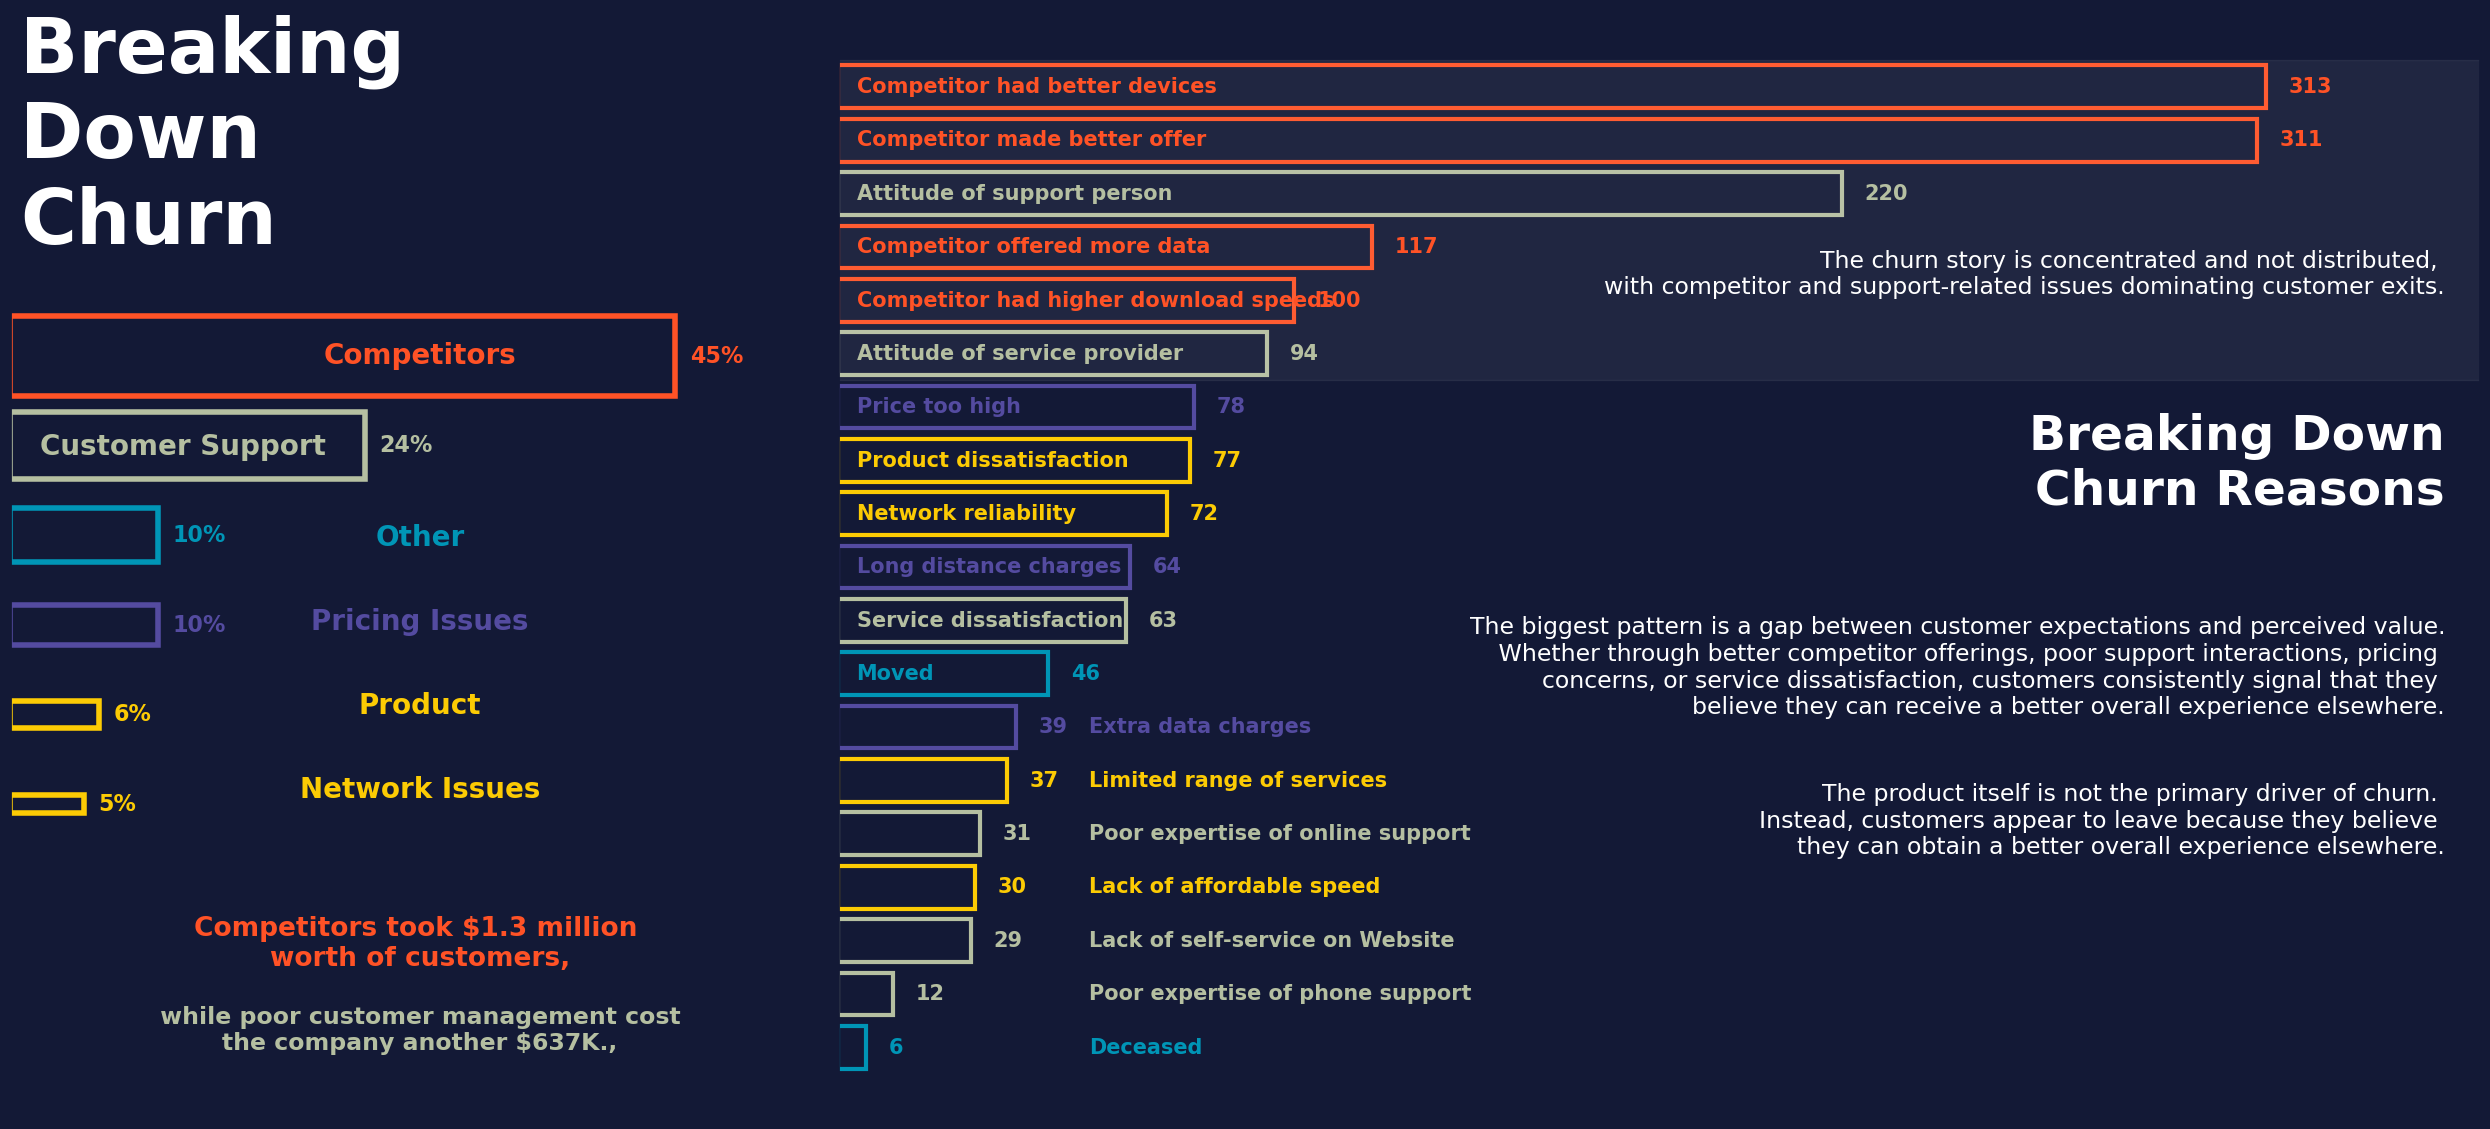

In [20]:
fig = plt.figure(figsize=(25,14),facecolor=facecolor,dpi=100)
ax1 = plt.subplot2grid((4,3),(0,0),colspan=1)
ax2 = plt.subplot2grid((4,3),(1,0),colspan=1,rowspan=2)
labels = ['Competitors','Customer Support','Other','Pricing','Product','Network']
values = [45,24,10,10,6,5]
colors = [all1,grey,stay,stayat,churn,churn]
heights = [0.9,0.75,0.6,0.45,0.3,0.2]

for i,(val,c,h) in enumerate(zip(values,colors,heights)):
    ax2.barh(i,val,height=h,color='none',edgecolor=c,linewidth=4)
    ax2.text(val+1,i,f'{val}%',va='center',ha='left',fontsize=16,color=c,fontweight='bold')

ax2.set_xlim(0,55)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.invert_yaxis()
ax3 = plt.subplot2grid((4,3),(3,0),colspan=1)
ax4 = plt.subplot2grid((4,3),(0,1),colspan=2,rowspan=4)
categories=['Competitors','Customer Support','Other','Pricing','Product','Network']
colors=[all1,grey,stay,stayat,churn,churn]
categories=['Competitors','Customer Support','Other','Pricing','Product','Network']
colors=[all1,grey,stay,stayat,churn,churn]

reason_df=prepared.groupby(['Churn_Category','Churn Reason']).size().reset_index(name='Count')
reason_df['Color']=reason_df['Churn_Category'].map(dict(zip(categories,colors)))
reason_df=reason_df.sort_values('Count',ascending=False).reset_index(drop=True)
reason_df = reason_df[reason_df["Churn Reason"] != "Don't know"]
y=np.arange(len(reason_df))
bars=ax4.barh(y,reason_df['Count'],color='none',edgecolor=reason_df['Color'],linewidth=3)
for i,(cnt,c) in enumerate(zip(reason_df['Count'],reason_df['Color'])):
    ax4.text(cnt+5,i,f'{cnt}',va='center',ha='left',fontsize=15,color=c,fontweight='bold')
for i,(reason,c) in enumerate(zip(reason_df['Churn Reason'][:12],reason_df['Color'][:12])):
    ax4.text(4,i,reason,va='center',ha='left',fontsize=15,fontweight='bold',color=c)
for i,(reason,c) in enumerate(zip(reason_df['Churn Reason'][12:],reason_df['Color'][12:]),start=12):
    ax4.text(55,i,reason,va='center',ha='left',fontsize=15,fontweight='bold',color=c)
ax4.set_xlim(0,reason_df['Count'].max()*1.15)
ax4.set_xticks([])
ax4.set_yticks([])
ax4.invert_yaxis()
for ax in [ax1,ax2,ax3,ax4]:
    ax.set_facecolor(facecolor)
    [spine.set(color=facecolor,linewidth=2) for spine in ax.spines.values()]
for ax in [ax1,ax2,ax3,ax4]: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Breaking \nDown \nChurn",x=0.01,y=0.8,fontsize=55,color="white",fontweight="bold",ha="left")
fig.text(0.17,0.12,"Competitors took $1.3 million \nworth of customers,",fontsize=19,fontweight="bold",color=all1,ha="center")
fig.text(0.17,0.06," while poor customer management cost \nthe company another $637K.,",fontsize=17,fontweight="bold",color=grey,ha="center")
fig.text(0.98,0.45,"Breaking Down\nChurn Reasons",fontsize=35,fontweight="bold",color="white",ha="right")
fig.text(0.98,0.3,"The biggest pattern is a gap between customer expectations and perceived value.\n Whether through better competitor offerings, poor support interactions, pricing \nconcerns, or service dissatisfaction, customers consistently signal that they \nbelieve they can receive a better overall experience elsewhere.",
         fontsize=17,fontweight="regular",color="white",ha="right")
fig.text(0.98,0.6,"The churn story is concentrated and not distributed, \nwith competitor and support-related issues dominating customer exits.",
         fontsize=17,fontweight="regular",color="white",ha="right")
fig.text(0.98,0.2,"The product itself is not the primary driver of churn. \nInstead, customers appear to leave because they believe \nthey can obtain a better overall experience elsewhere.",
         fontsize=17,fontweight="regular",color="white",ha="right")
fig.text(0.17,0.55,"Competitors",fontsize=20,fontweight="bold",color=all1,ha="center")
fig.text(0.075,0.485,"Customer Support",fontsize=20,fontweight="bold",color=grey,ha="center")
fig.text(0.17,0.42,"Other",fontsize=20,fontweight="bold",color=stay,ha="center")
fig.text(0.17,0.36,"Pricing Issues",fontsize=20,fontweight="bold",color=stayat,ha="center")
fig.text(0.17,0.3,"Product",fontsize=20,fontweight="bold",color=churn,ha="center")
fig.text(0.17,0.24,"Network Issues",fontsize=20,fontweight="bold",color=churn,ha="center")
ax4.axhspan(-0.5,5.5,color="white",alpha=0.06)
# plt.savefig("churn reasons final one.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

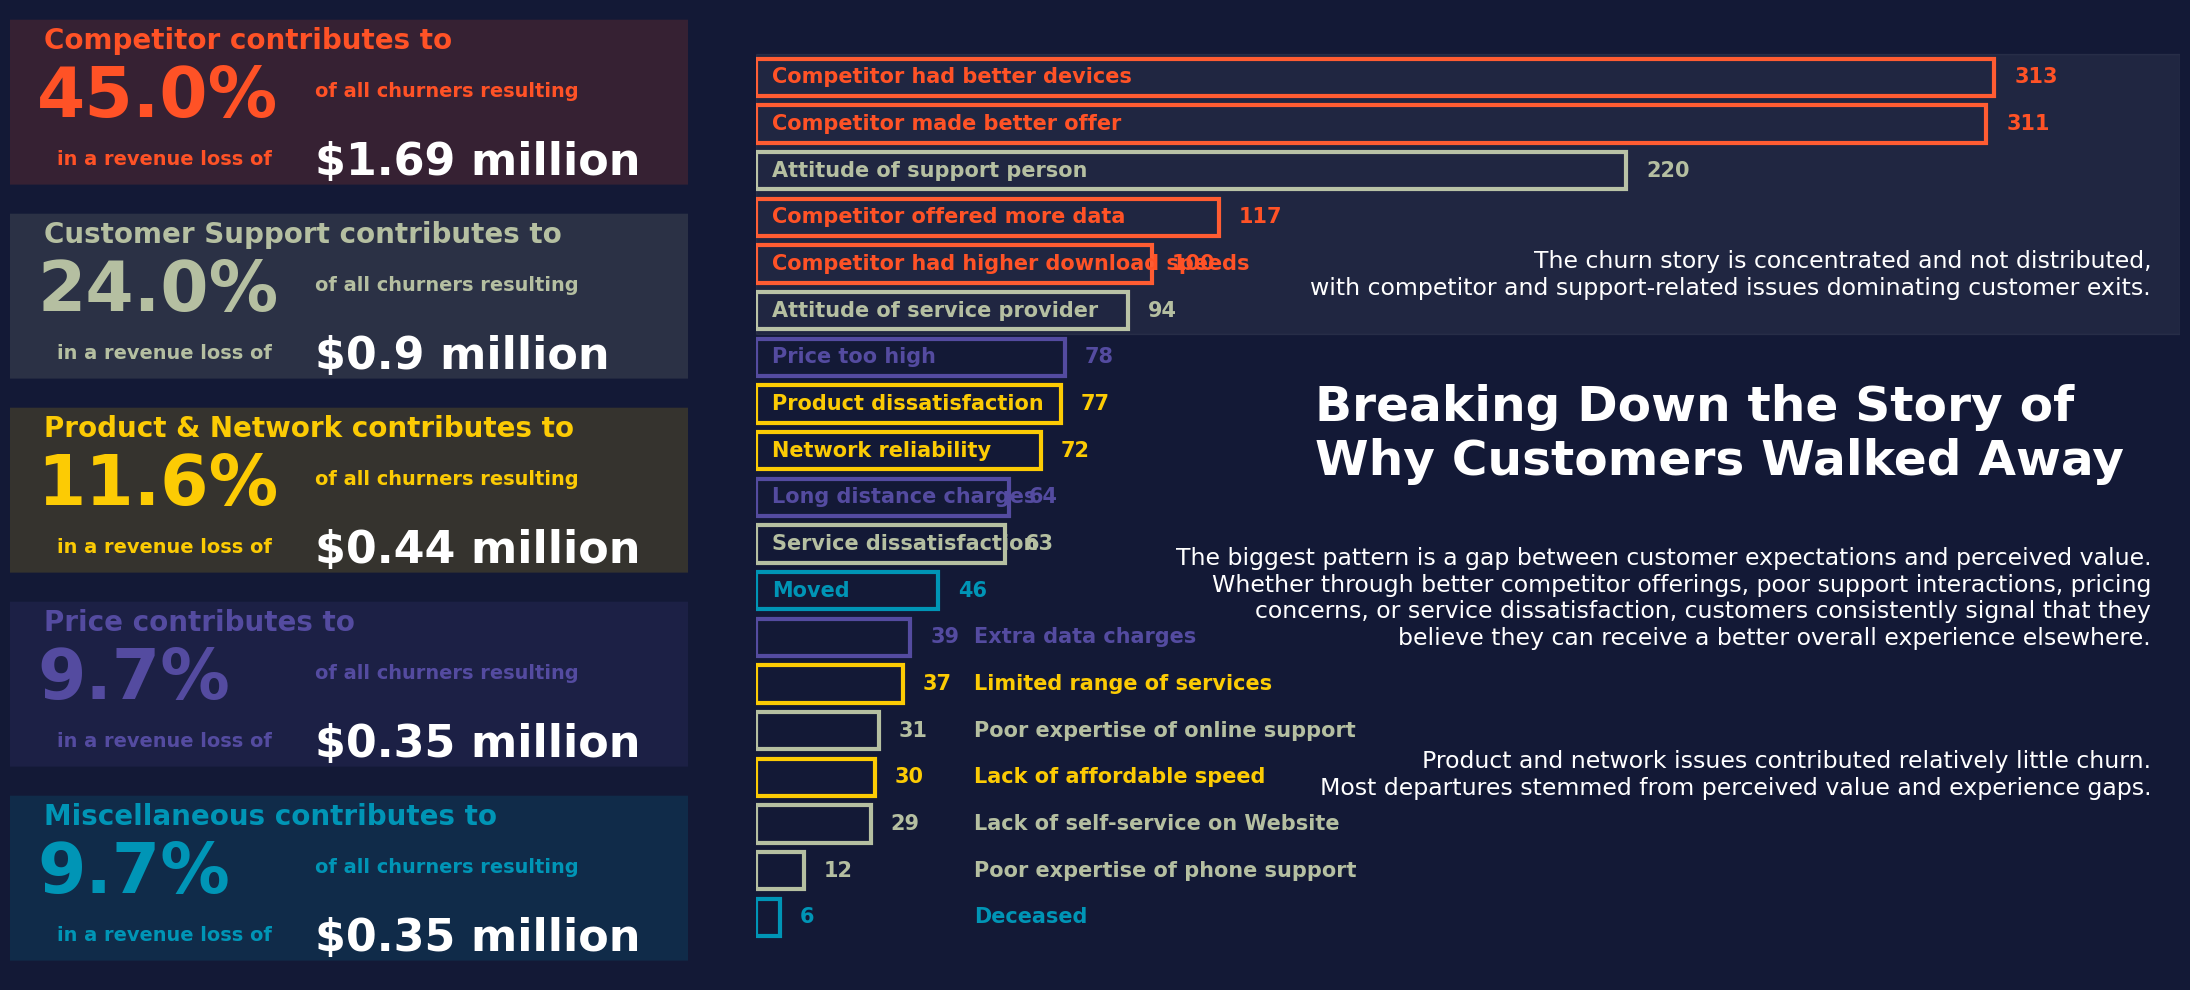

In [21]:
data = [{"label":"Competitor","pct":45.0,"rev":1.69},{"label":"Customer Support","pct":24.0,"rev":0.90},{"label":"Product & Network","pct":11.6,"rev":0.44},{"label":"Price","pct":9.7,"rev":0.35},{"label":"Miscellaneous","pct":9.7,"rev":0.35}, ]
y_starts = [0.85, 0.65, 0.45, 0.25, 0.05]
fig = plt.figure(figsize=(22,10), facecolor=facecolor, dpi=100)
ax_pillar = plt.subplot2grid((5,3), (0,0), rowspan=5, colspan=1)
ax_pillar.set_facecolor(facecolor)
ax_pillar.axis('off')
color_map = {"Competitor": all1,"Customer Support": grey,"Miscellaneous": stay,"Price": stayat,"Product & Network": churn}
for i, y in enumerate(y_starts):
    d = data[i]
    col = color_map[d["label"]]
    container = patches.FancyBboxPatch( (0.0, y), 1.3, 0.11, boxstyle="round,pad=0.03", linewidth=0,facecolor=col,alpha=0.15,transform=ax_pillar.transAxes)
    ax_pillar.add_patch(container)
    ax_pillar.text(0.05, y+0.11, f"{d['label']} contributes to",fontsize=20, color=col, fontweight="bold",transform=ax_pillar.transAxes)
    ax_pillar.text(0.04, y+0.04, f"{d['pct']}%",fontsize=50, color=col, fontweight="bold",transform=ax_pillar.transAxes)
    ax_pillar.text(0.45, y+0.06, "of all churners resulting",fontsize=14, color=col, fontweight="bold",transform=ax_pillar.transAxes)
    ax_pillar.text(0.07, y-0.01, "in a revenue loss of",fontsize=14, color=col, fontweight="bold",transform=ax_pillar.transAxes)
    ax_pillar.text(0.45, y-0.02, f"${d['rev']} million",fontsize=32, color="white", fontweight="bold",transform=ax_pillar.transAxes)
ax4 = plt.subplot2grid((5,3), (0,1), colspan=2, rowspan=5)
ax4.set_facecolor(facecolor)
ax4.axis('off')
categories = ['Competitors','Customer Support','Other','Pricing','Product','Network']
colors = [all1,grey,stay,stayat,churn,churn]
reason_df = prepared.groupby(['Churn_Category','Churn Reason']).size().reset_index(name='Count')
reason_df['Color'] = reason_df['Churn_Category'].map(dict(zip(categories,colors)))
reason_df = reason_df.sort_values('Count', ascending=False).reset_index(drop=True)
reason_df = reason_df[reason_df["Churn Reason"] != "Don't know"]
y = np.arange(len(reason_df))
bars = ax4.barh(y, reason_df['Count'], color='none',edgecolor=reason_df['Color'], linewidth=3)
for i, (cnt, c) in enumerate(zip(reason_df['Count'], reason_df['Color'])):
    ax4.text(cnt+5, i, f'{cnt}', va='center', ha='left',fontsize=15, color=c, fontweight='bold')
for i, (reason, c) in enumerate(zip(reason_df['Churn Reason'][:12], reason_df['Color'][:12])):
    ax4.text(4, i, reason, va='center', ha='left',fontsize=15, fontweight='bold', color=c)
for i, (reason, c) in enumerate(zip(reason_df['Churn Reason'][12:], reason_df['Color'][12:]), start=12):
    ax4.text(55, i, reason, va='center', ha='left',fontsize=15, fontweight='bold', color=c)
ax4.set_xlim(0, reason_df['Count'].max()*1.15)
ax4.set_xticks([]);ax4.set_yticks([]);ax4.invert_yaxis()
fig.text(0.6,0.52,"Breaking Down the Story of\nWhy Customers Walked Away",fontsize=35,fontweight="bold",color="white")
fig.text(0.98,0.35,"The biggest pattern is a gap between customer expectations and perceived value.\nWhether through better competitor offerings, poor support interactions, pricing\nconcerns, or service dissatisfaction, customers consistently signal that they\nbelieve they can receive a better overall experience elsewhere.",
         fontsize=17,color="white",ha="right")
fig.text(0.98,0.7,"The churn story is concentrated and not distributed,\nwith competitor and support-related issues dominating customer exits.",
         fontsize=17,color="white",ha="right")
fig.text(0.98,0.2,"Product and network issues contributed relatively little churn.\nMost departures stemmed from perceived value and experience gaps.",
         fontsize=17,color="white",ha="right")
ax4.axhspan(-0.5,5.5,color="white",alpha=0.06)
# plt.savefig("churn reasons final two.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

In [22]:
prepared["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [23]:
risk_columns = ['Contract', 'Online Security', 'Premium Tech Support', 'Paperless Billing',
                'Payment Method', 'Internet Type', 'Online Backup', 'Device Protection Plan',
                'Offer', 'Streaming Music', 'Streaming TV']
global_churn_rate = (prepared['Customer Status'] == 'Churned').mean()
total_churned = (prepared['Customer Status'] == 'Churned').sum()
lift_results = []
for col in risk_columns:
    categories = prepared[col].unique()
    for cat in categories:
        group = prepared[prepared[col] == cat]
        customer_count = len(group)
        churn_count = (group['Customer Status'] == 'Churned').sum()
        churn_rate = (group['Customer Status'] == 'Churned').mean()
        lift_pct = ((churn_rate / global_churn_rate) - 1) * 100
        contribution_pct = (churn_count / total_churned) * 100
        lift_results.append({
            'Feature': f'{col}: {cat}','Customer_Count': customer_count,'Churned_Count': churn_count,'Churn_Rate': churn_rate * 100,'Lift_Percentage': lift_pct,'Contribution_Percentage': contribution_pct })
lift_df = pd.DataFrame(lift_results).sort_values('Lift_Percentage',ascending=False).reset_index(drop=True)

In [24]:
risk_columns = ['Contract', 'Online Security', 'Premium Tech Support', 'Paperless Billing',
                'Payment Method', 'Internet Type', 'Online Backup', 'Device Protection Plan',
                'Offer', 'Streaming Music', 'Streaming TV']
global_churn_rate = (prepared['Customer Status'] == 'Churned').mean()
lift_results = []
for col in risk_columns:
    categories = prepared[col].unique()
    for cat in categories:
        group = prepared[prepared[col] == cat]
        customer_count = len(group)
        churn_count = (group['Customer Status'] == 'Churned').sum()
        churn_rate = (group['Customer Status'] == 'Churned').mean()
        lift_pct = ((churn_rate / global_churn_rate) - 1) * 100
        lift_results.append({'Feature': f'{col}: {cat}','Customer_Count': customer_count,'Churned_Count': churn_count,'Contribution_Percentage': churn_rate * 100,'Lift_Percentage': lift_pct})

lift_df = pd.DataFrame(lift_results).sort_values('Lift_Percentage', ascending=False).reset_index(drop=True)

In [25]:
lift_df

,Feature,Customer_Count,Churned_Count,Contribution_Percentage,Lift_Percentage
0,Offer: Offer E,805,426,52.919255,99.416967
1,Contract: Month-to-Month,3610,1655,45.844875,72.758404
2,Online Security: No,3498,1461,41.766724,57.390602
3,Premium Tech Support: No,3473,1446,41.635474,56.896009
4,Internet Type: Fiber Optic,3035,1236,40.724876,53.464583
5,Online Backup: No,3088,1233,39.928756,50.464544
6,Device Protection Plan: No,3095,1211,39.127625,47.445620
7,Payment Method: Mailed Check,385,142,36.883117,38.987583
8,Payment Method: Bank Withdrawal,3909,1329,33.998465,28.117276
9,Streaming Music: No,3029,1028,33.938594,27.891661


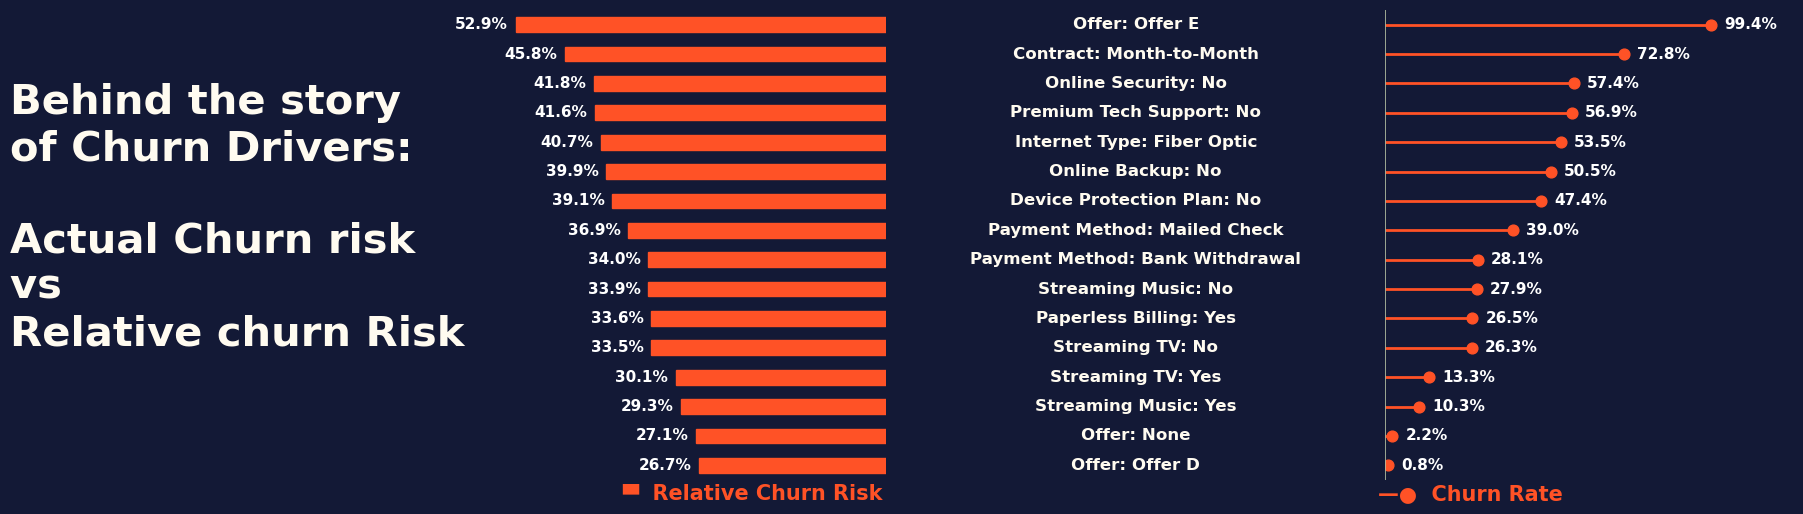

In [26]:
plot_df = lift_df.head(16).copy()
y = np.arange(len(plot_df))
fig, ax = plt.subplots(nrows=1,ncols=4,figsize=(18,5),dpi=100)
fig.patch.set_facecolor(facecolor)
# ax_empty = ax[0]
# ax_contrib = ax[1]
# ax_feat = ax[2]
# ax_lift = ax[3]
ax_empty, ax_contrib, ax_feat, ax_lift = ax
for a in [ax_empty, ax_contrib, ax_feat, ax_lift]:
    a.set_facecolor(facecolor)
# ---------- EMPTY ---------- #
ax_empty.set_xticks([]);ax_empty.set_yticks([])
for spine in ax_empty.spines.values():
    spine.set_visible(False)
# ---------- ACTUAL CHURN RATE (RIGHT -> LEFT) ---------- #
contrib_max = plot_df['Contribution_Percentage'].max()
ax_contrib.barh(y,plot_df['Contribution_Percentage'],color=all1,edgecolor=all1,height=0.5)
ax_contrib.set_xlim(contrib_max * 1.1, 0)
ax_contrib.set_ylim(len(plot_df)-0.5, -0.5)
for i, val in enumerate(plot_df['Contribution_Percentage']):
    ax_contrib.text(val + contrib_max * 0.02,i,f'{val:.1f}%',va='center',ha='right',fontsize=11,color="white",fontweight='bold')
ax_contrib.set_xticks([])
ax_contrib.set_yticks([])
# ---------- FEATURES ---------- #
ax_feat.set_xlim(0, 1)
ax_feat.set_ylim(len(plot_df)-0.5, -0.5)
for i, feat in enumerate(plot_df['Feature']):
    ax_feat.text(0.5,i,feat,ha='center',va='center',fontsize=12,fontweight='bold',color='#fffbf0')
ax_feat.set_xticks([]);ax_feat.set_yticks([])
# ---------- RELATIVE CHURN RISK (LEFT -> RIGHT) ---------- #
lift_max = plot_df['Lift_Percentage'].max()
ax_lift.set_xlim(0, lift_max * 1.25)
ax_lift.set_ylim(len(plot_df)-0.5, -0.5)
for i, val in enumerate(plot_df['Lift_Percentage']):
    ax_lift.hlines(i, 0, val, color=all1, linewidth=2)
    ax_lift.scatter(val, i, color=all1, s=60)
    ax_lift.text(val + 4,i,f'{val:.1f}%',va='center',ha='left',fontsize=11,color="white",fontweight='bold')
ax_lift.axvline(0, color=grey, linewidth=1.2)
ax_lift.set_xticks([]);ax_lift.set_yticks([])
# ---------- CLEANUP ---------- #
for a in [ax_contrib, ax_feat, ax_lift]:
    for spine in a.spines.values():
        spine.set_visible(False)
fig.text(0.0,0.3,'Behind the story \nof Churn Drivers: \n\nActual Churn risk \nvs \nRelative churn Risk',fontsize=30,color='#fffbf0',fontweight='bold')
fig.text(0.34, -0.01, "▀  Relative Churn Risk", fontsize=15, color=all1, fontweight="bold")
fig.text(0.76, -0.01, "—●  Churn Rate", fontsize=15, color=all1, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
def generate_kpi_plot(ax, bg_color, font_color, revenue_num, percent_num, avg_charge_num, customer_base_num):
    ax.patch.set_facecolor(bg_color)
    ax.text(0.5, 0.8, "Revenue Generated", fontsize=15, ha="center", fontweight="bold", color=font_color)
    ax.text(0.5, 0.5, f"$ {revenue_num}", fontsize=40, ha="center", fontweight="bold", color=font_color)
    ax.text(0.5, 0.37, f"({percent_num}%)", fontsize=10, ha="center", fontweight="bold", color=font_color)
    ax.text(0.25, 0.18, f"Avg. Charges: \n$ {avg_charge_num}", fontsize=15, ha="center", fontweight="bold", color=font_color)
    ax.text(0.75, 0.18, f"Customer Base: \n{customer_base_num}", fontsize=15, ha="center", fontweight="bold", color=font_color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

In [28]:
# facecolor = "#1c1c26"
# stay = "#fccb04"
# churn = "#0095b6"
white = "#ffffff" 
grey = "#b5bfa1"

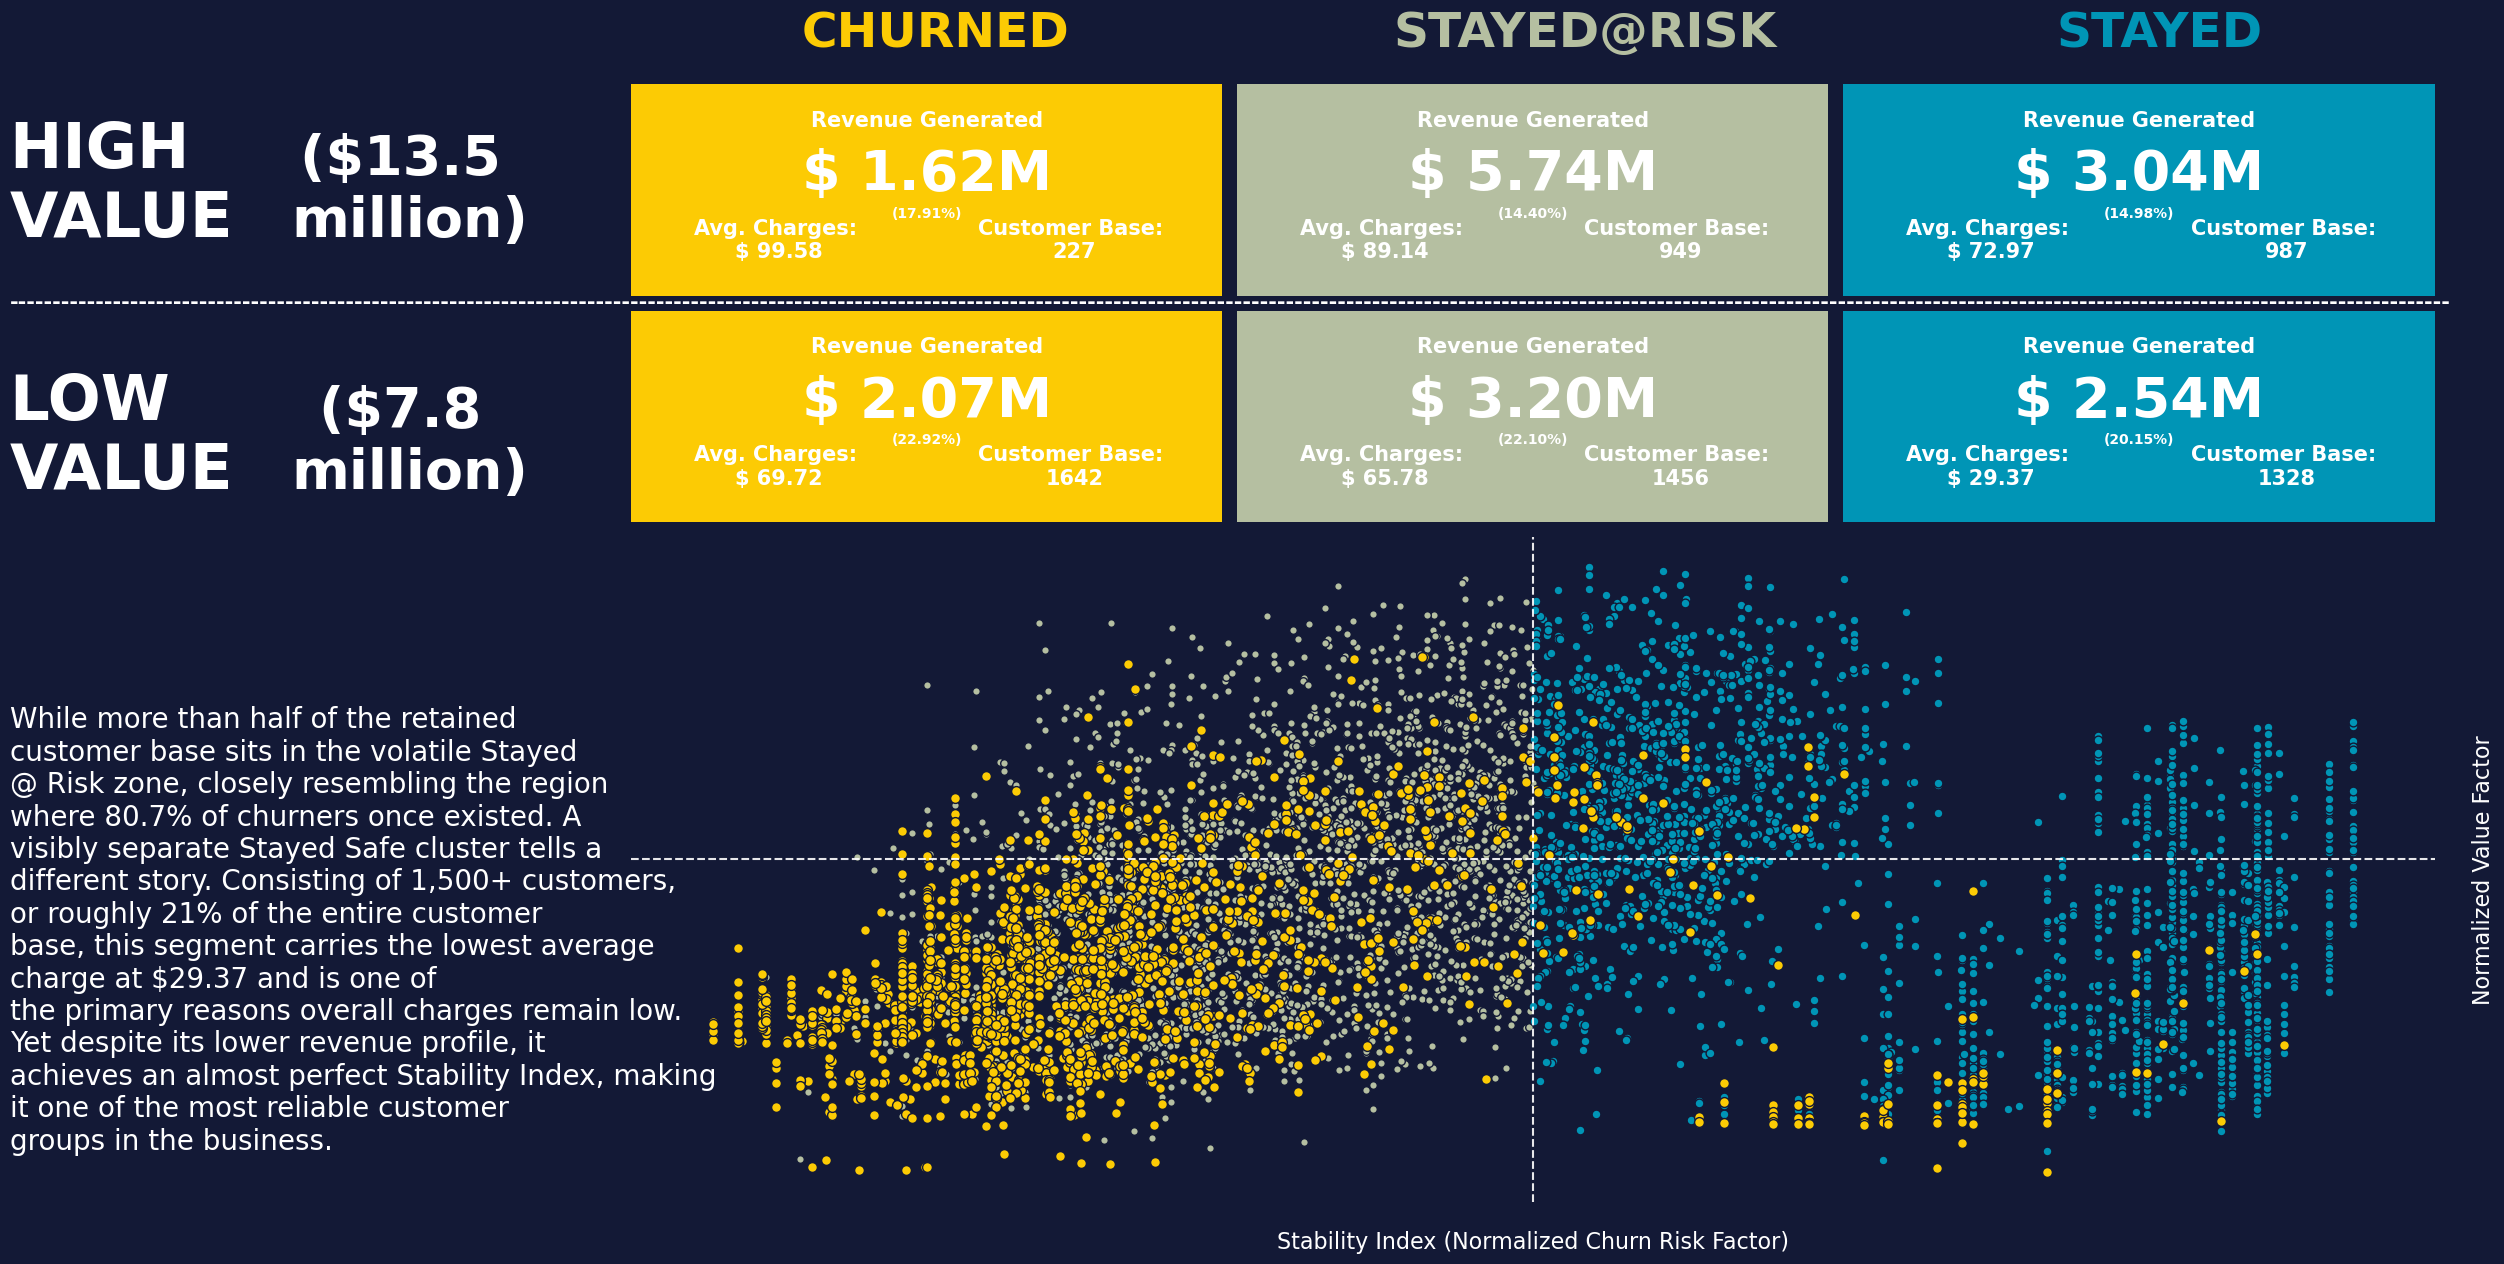

In [29]:
fig = plt.figure(figsize=(25, 12), facecolor=facecolor)
ax00 = plt.subplot2grid((5, 4), (0, 0))
ax10 = plt.subplot2grid((5, 4), (1, 0))
ax20 = plt.subplot2grid((5, 4), (2, 0))
ax30 = plt.subplot2grid((5, 4), (3, 0))
ax40 = plt.subplot2grid((5, 4), (4, 0))

ax11 = plt.subplot2grid((5, 4), (0, 1))
ax12 = plt.subplot2grid((5, 4), (1, 1))
ax13 = plt.subplot2grid((5, 4), (0, 2))
ax14 = plt.subplot2grid((5, 4), (1, 2))
ax15 = plt.subplot2grid((5, 4), (0, 3))
ax16 = plt.subplot2grid((5, 4), (1, 3))

for ax in [ax00, ax10, ax20, ax30, ax40, ax11, ax12, ax13, ax14, ax15, ax16]:
    ax.set_facecolor(facecolor)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

generate_kpi_plot(ax=ax11, bg_color=churn, font_color=white, revenue_num="1.62M", percent_num="17.91", avg_charge_num="99.58", customer_base_num="227")
generate_kpi_plot(ax=ax12, bg_color=churn, font_color=white, revenue_num="2.07M", percent_num="22.92", avg_charge_num="69.72", customer_base_num="1642")

generate_kpi_plot(ax=ax13, bg_color=grey, font_color=white, revenue_num="5.74M", percent_num="14.40", avg_charge_num="89.14", customer_base_num="949")
generate_kpi_plot(ax=ax14, bg_color=grey, font_color=white, revenue_num="3.20M", percent_num="22.10", avg_charge_num="65.78", customer_base_num="1456")

generate_kpi_plot(ax=ax15, bg_color=stay, font_color=white, revenue_num="3.04M", percent_num="14.98", avg_charge_num="72.97", customer_base_num="987")
generate_kpi_plot(ax=ax16, bg_color=stay, font_color=white, revenue_num="2.54M", percent_num="20.15", avg_charge_num="29.37", customer_base_num="1328")

ax_scatter = plt.subplot2grid((5, 4), (2, 1), rowspan=3, colspan=3)
ax_scatter.patch.set_facecolor(facecolor)

color_map = {'Stayed @ Risk': grey, 'Stayed Safe': stay, 'Churned': churn}
alpha_map = {'Stayed @ Risk': 1.0, 'Stayed Safe': 1.0, 'Churned': 1.0}
size_map = {'Stayed @ Risk': 30, 'Stayed Safe': 40, 'Churned': 50}
edgecolor_map = {'Stayed @ Risk': facecolor, 'Stayed Safe': facecolor, 'Churned': facecolor}

for segment, color in color_map.items():
    subset = master_df[master_df['Strategic_Segment'] == segment]
    ax_scatter.scatter(
        subset['NCRF'], 
        subset['NVF'], 
        label=segment, 
        color=color, 
        alpha=alpha_map[segment], 
        edgecolors=edgecolor_map[segment], 
        s=size_map[segment]
    )

ax_scatter.axhline(0.5, color='white', linestyle='--', alpha=0.9)
ax_scatter.axvline(0.5, color='white', linestyle='--', alpha=0.9)
ax_scatter.set_xlabel('Stability Index (Normalized Churn Risk Factor)')
ax_scatter.set_ylabel('Normalized Value Factor')
ax_scatter.set_title("", color="white", fontsize=15)

for spine in ax_scatter.spines.values():
    spine.set_visible(False)

ax_scatter.xaxis.label.set_color('white')
ax_scatter.xaxis.label.set_size(16)
ax_scatter.tick_params(axis='x', colors=facecolor, labelcolor=facecolor)

ax_scatter.yaxis.set_label_position("right")
ax_scatter.yaxis.tick_right()
ax_scatter.yaxis.label.set_color('white')
ax_scatter.yaxis.label.set_size(16)
ax_scatter.tick_params(axis='y', which='both', right=True, colors=facecolor)
# for x_val in np.linspace(0.0, 1.0, 11):
#     fig.text(x=x_val, y=0.5, s=f"{x_val:.1f}", fontsize=25, color='white', ha='center', fontweight="bold",va='center')
#     fig.text(y=x_val, x=0.15, s=f"{x_val:.1f}", fontsize=25, color='white', ha='center', fontweight="bold",va='center',alpha=0.5)
fig.text(0.37,1.03,"CHURNED",fontsize= 35,color=churn,fontweight="bold",ha="center",va="center")
fig.text(0.63,1.03,"STAYED@RISK",fontsize= 35,color=grey,fontweight="bold",ha="center",va="center")
fig.text(0.86,1.03,"STAYED",fontsize= 35,color=stay,fontweight="bold",ha="center",va="center")
fig.text(0.0,0.86,"HIGH \nVALUE",fontsize= 45,color = white,fontweight="bold",ha="left")
fig.text(0.0,0.65,"LOW \nVALUE",fontsize= 45,color = white,fontweight="bold",ha="left")
fig.text(0.16,0.86,"($13.5 \nmillion)",fontsize= 40,color = white,fontweight="bold",ha="center")
fig.text(0.16,0.65,"($7.8 \nmillion)",fontsize= 40,color = white,fontweight="bold",ha="center")
fig.text(0.0,0.8,"-"*283,fontsize= 15,color = white,fontweight="bold")
fig.text(
    0.0, 0.1,
    "While more than half of the retained\n"
    "customer base sits in the volatile Stayed\n"
    "@ Risk zone, closely resembling the region\n"
    "where 80.7% of churners once existed. A\n"
    "visibly separate Stayed Safe cluster tells a\n"
    "different story. Consisting of 1,500+ customers,\n"
    "or roughly 21% of the entire customer\n"
    "base, this segment carries the lowest average\n"
    "charge at $29.37 and is one of\n"
    "the primary reasons overall charges remain low.\n"
    "Yet despite its lower revenue profile, it\n"
    "achieves an almost perfect Stability Index, making\n"
    "it one of the most reliable customer\n"
    "groups in the business.",
    fontsize=20,
    color=white,
    fontweight="regular",
    ha="left"
)
# plt.savefig("fully fledges churn, stayed and stayed at risk 2.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

In [30]:
connectivity_no = ['Internet Service']
service_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
fortress_mask = (prepared['Internet Service'] == 'No')
fortress_cluster = prepared[fortress_mask]
cluster_size = len(fortress_cluster)

print(f"Total Points in Cluster: {cluster_size}\n")

for col in connectivity_no:
    cluster_count = (fortress_cluster[col] == 'No').sum()
    total_in_company = (prepared[col] == 'No').sum()
    capture_rate = (cluster_count / total_in_company) * 100
    print(f"{col}: {cluster_count} points | {capture_rate:.1f}% Capture (Target: 'No')")

for col in service_cols:
    cluster_count = (fortress_cluster[col] == 'None').sum()
    total_in_company = (prepared[col] == 'None').sum()
    capture_rate = (cluster_count / total_in_company) * 100
    print(f"{col}: {cluster_count} points | {capture_rate:.1f}% Capture (Target: 'None')")

Total Points in Cluster: 1526

Internet Service: 1526 points | 100.0% Capture (Target: 'No')
Online Security: 1526 points | 100.0% Capture (Target: 'None')
Online Backup: 1526 points | 100.0% Capture (Target: 'None')
Device Protection Plan: 1526 points | 100.0% Capture (Target: 'None')
Premium Tech Support: 1526 points | 100.0% Capture (Target: 'None')
Streaming TV: 1526 points | 100.0% Capture (Target: 'None')
Streaming Movies: 1526 points | 100.0% Capture (Target: 'None')
Streaming Music: 1526 points | 100.0% Capture (Target: 'None')


In [31]:
# Calculating the percentage of 'Stayed' customers within the identified segment
total_segment_customers = (prepared['Internet Service'] == 'No') & (prepared['Phone Service'] == 'Yes')
stayed_count = ((prepared['Customer Status'] == 'Stayed') & total_segment_customers).sum()
total_count = total_segment_customers.sum()
stayed_percentage = (stayed_count / total_count) * 100
print(f"Total Customers in Segment: {total_count}")
print(f"Customers who Stayed: {stayed_count}")
print(f"Percentage of People who Stayed: {stayed_percentage:.2f}%")

Total Customers in Segment: 1526
Customers who Stayed: 1231
Percentage of People who Stayed: 80.67%


In [32]:
# Filtering for the 1,231 customers (Non-Digital Stayed Segment)
fortress_mask = (prepared['Internet Service'] == 'No') & \
                (prepared['Phone Service'] == 'Yes') & \
                (prepared['Customer Status'] == 'Stayed')

# Calculate Revenue Metrics
segment_revenue = prepared[fortress_mask]['Total Revenue'].sum()
total_company_revenue = prepared['Total Revenue'].sum()
revenue_percentage = (segment_revenue / total_company_revenue) * 100

print(f"Total Revenue held by Segment: ${segment_revenue:,.2f}")
print(f"Percentage of Total Company Revenue: {revenue_percentage:.2f}%")

Total Revenue held by Segment: $2,129,501.17
Percentage of Total Company Revenue: 9.96%


In [33]:
mask_none=(
    (prepared['Internet Service']=='No')&
    (prepared['Internet Type']=='None')&
    (prepared['Online Security']=='None')&
    (prepared['Online Backup']=='None')&
    (prepared['Streaming TV']=='None')&
    (prepared['Streaming Movies']=='None')&
    (prepared['Streaming Music']=='None')
)
none_df = prepared[mask_none]

count_none = len(none_df)
pct_none = (count_none / len(prepared)) * 100 if len(prepared) > 0 else 0.0
pct_stayed = (
    (len(none_df[none_df["Customer Status"] == "Stayed"]) / count_none) * 100
    if count_none > 0
    else 0.0
)

print(f"Count: {count_none}")
print(f"Percentage of Total: {pct_none:.2f}%")
print(f"Percentage of These Who Stayed: {pct_stayed:.2f}%")

Count: 1526
Percentage of Total: 21.67%
Percentage of These Who Stayed: 80.67%


In [34]:
mask=(prepared['Internet Service'].eq('No')&
      prepared['Phone Service'].eq('Yes')&
      prepared['Online Security'].eq('None')&
      prepared['Online Backup'].eq('None')&
      prepared['Device Protection Plan'].eq('None')&
      prepared['Premium Tech Support'].eq('None')&
      prepared['Streaming TV'].eq('None')&
      prepared['Streaming Movies'].eq('None')&
      prepared['Streaming Music'].eq('None')&
      prepared['Unlimited Data'].isna())

prepared['Retention_Flag']=np.where(mask,'Yes','No')

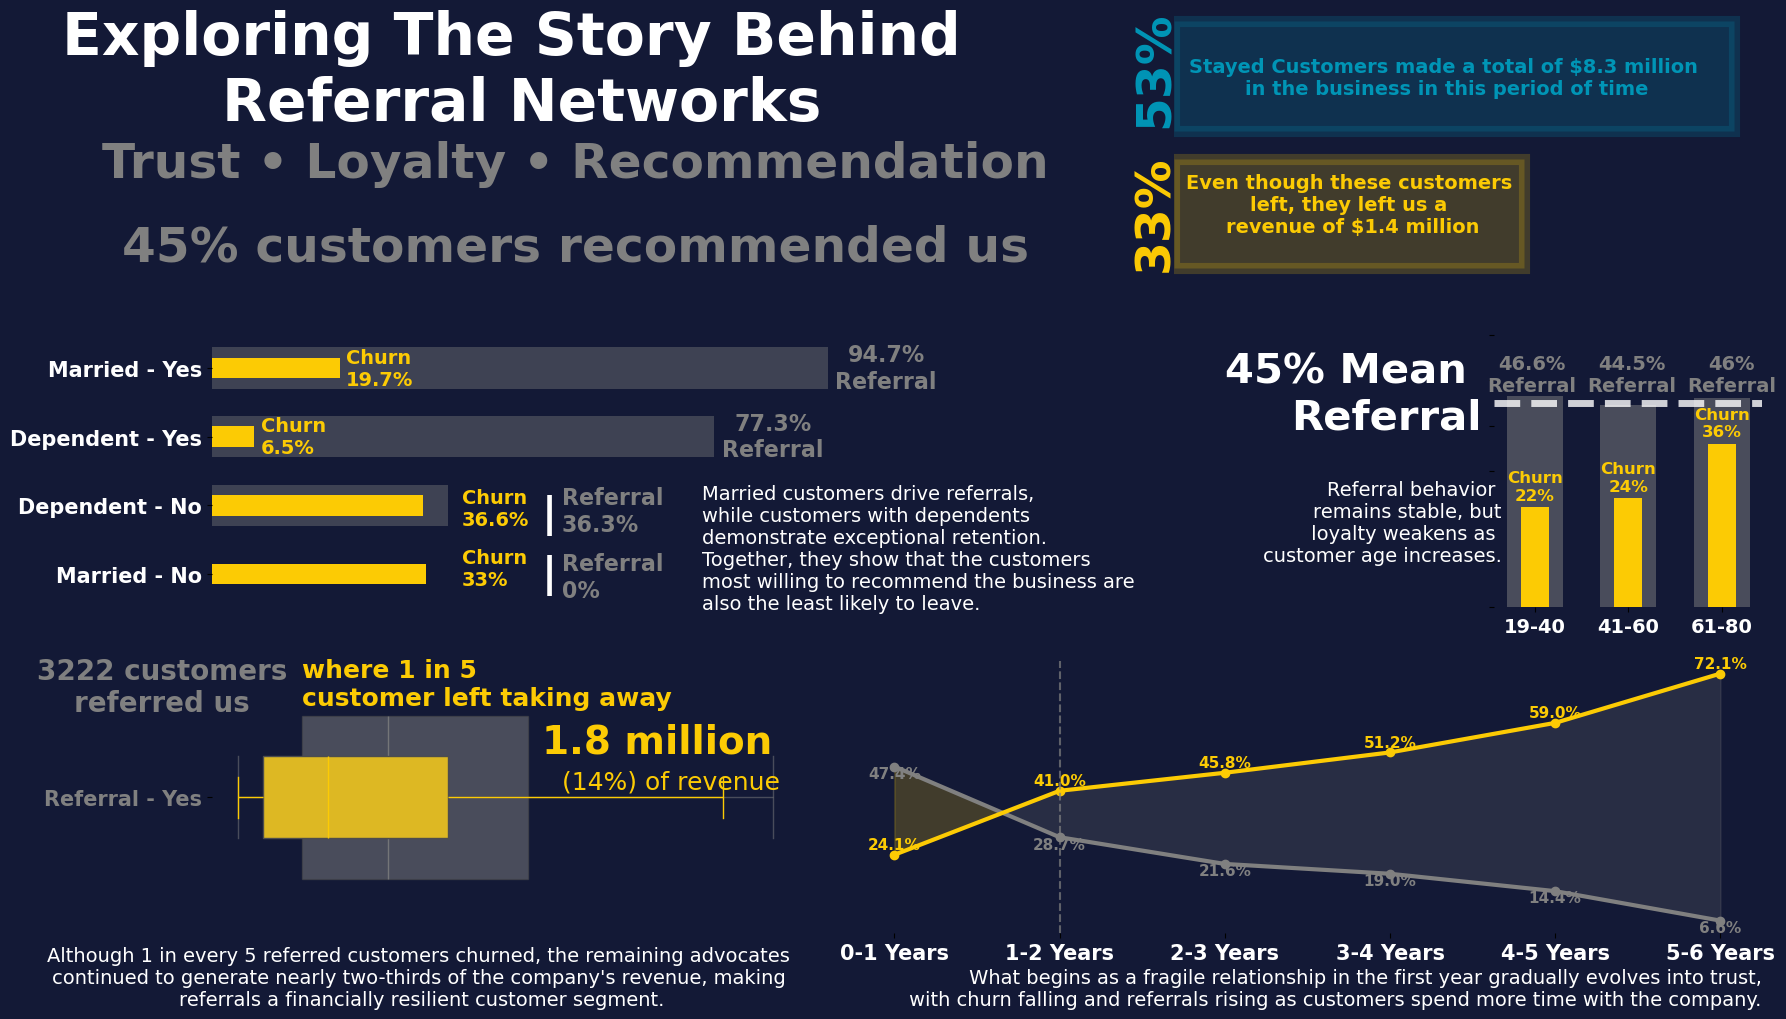

In [35]:
fig = plt.figure(figsize=(20, 12), facecolor=facecolor, dpi=100)
# the empty cell
ax1 = plt.subplot2grid((3, 5), (0, 0), colspan=3)
# the barplot of customer status
ax2 = plt.subplot2grid((3, 5), (0, 3), colspan=2)
referral_pct = ((prepared[prepared["Referral Flag"] == "Yes"].groupby("Customer Status").size() / prepared.groupby("Customer Status").size()) * 100).reset_index(name="Referral_Pct")
referral_pct = referral_pct[referral_pct["Customer Status"] != "Joined"]
colors = [stay if x == "Stayed" else churn for x in referral_pct["Customer Status"]]
bars = ax2.barh(referral_pct["Customer Status"], referral_pct["Referral_Pct"],edgecolor=colors, color=colors,alpha=0.2, linewidth=8)
# for bar, val, c in zip(bars, referral_pct["Referral_Pct"], colors):
#     ax2.text(val + 1, bar.get_y() + bar.get_height()/2,f"{val:.1f}%", va='center', color=c, fontsize=35, fontweight='bold')
#     # ax2.text(val + 1, bar.get_y() + bar.get_height()/2,f"{val:.1f}%", va='center', color=c, fontsize=30, fontweight='bold')
ax2.set_xticks([]);ax2.set_yticks([])
# the married barplot 
ax3 = plt.subplot2grid((3, 5), (1, 0),colspan=3)
categories = [("Married", "Yes", "Married - Yes"),("Dependent Flag", "Yes", "Dependent - Yes"),("Dependent Flag", "No", "Dependent - No"),("Married", "No", "Married - No"),  ]
labels = []
referral_pct = []
churn_pct = []
totals = []
for col, val, label in categories:
    subset = prepared[prepared[col] == val]
    labels.append(label)
    totals.append(len(subset))
    referral_pct.append((subset["Referral Flag"] == "Yes").mean() * 100)
    churn_pct.append((subset["Customer Status"] == "Churned").mean() * 100)
y = np.arange(len(labels))
ax3.barh(y, referral_pct, height=0.6, color="grey", alpha=0.4, label="Referral")
ax3.barh(y, churn_pct, height=0.3, color=churn, label="Churn")
ax3.set_yticks(y)
ax3.set_yticklabels(labels, fontsize=15, color="white", fontweight="bold")
for i, (ref, churn_rate) in enumerate(zip(referral_pct[:2], churn_pct[:2])):
    ax3.text(ref + 9, i, f"{ref:.1f}%\nReferral", color="grey", fontsize=16, fontweight="bold", ha="center", va="center")
    ax3.text(churn_rate + 1, i, f"Churn \n{churn_rate:.1f}%", color=churn, fontsize=14, fontweight="bold", va="center")
ax3.set_xticks([]);ax3.set_xlim(0, max(referral_pct) + 45);ax3.invert_yaxis()
for spine in ax3.spines.values():
    spine.set_visible(False)
# the age group
ax5 = plt.subplot2grid((3, 5), (1, 4),colspan=1)
ax5.patch.set_facecolor(facecolor)
ref_pct = ((prepared[prepared["Referral Flag"] == "Yes"].groupby("Age Group").size()
            / prepared.groupby("Age Group").size()) * 100).reindex(["19-40", "41-60", "61-80"])
churn_pct = [22, 24, 36]
x = np.arange(len(ref_pct))
# Broad bars
ax5.bar(x, ref_pct, width=0.6, color="grey", alpha=0.5)
# Narrow bars
ax5.bar(x, churn_pct, width=0.3, color=churn)
# Churn labels
for i, val in enumerate(churn_pct):
    ax5.text(i, val + 1, f"Churn\n{val}%", ha="center", va="bottom",fontsize=12, color=churn, fontweight="bold")
ax5.set_xticks(x);ax5.set_xticklabels(ref_pct.index, fontsize=14, color="white", fontweight="bold")
ax5.set_yticks(np.arange(0, 61, 10));ax5.set_yticklabels(np.arange(0, 61, 10), fontsize=12, color=facecolor)
ax5.axhline(y=45, color="white", linestyle="--", linewidth=5, alpha=0.8)
for spine in ax5.spines.values():
    spine.set_visible(False)
# the kde plot of NVF
ax6 = plt.subplot2grid((3, 5), (2, 0), colspan=2)
# Main boxplot (Referral = Yes only)
sns.boxplot(data=prepared[prepared["Referral Flag"]=="Yes"],y="Referral Flag",x="Total Revenue",showfliers=False,color="grey",width=0.6,ax=ax6,
    zorder=5,boxprops=dict(alpha=0.5),whiskerprops=dict(color="grey", alpha=0.5),capprops=dict(color="grey", alpha=0.5),medianprops=dict(color="grey", alpha=0.8))
# Overlapping narrow boxplot (Churned & Referral = Yes)
sns.boxplot(data=prepared[(prepared["Referral Flag"]=="Yes") &(prepared["Customer Status"]=="Churned")],y="Referral Flag",x="Total Revenue",showfliers=False,
    color=churn,width=0.3,ax=ax6,zorder=10,boxprops=dict(alpha=1),whiskerprops=dict(color=churn, alpha=1),capprops=dict(color=churn, alpha=1),medianprops=dict(color=churn, alpha=1.0))
ax6.set_yticklabels(["Referral - Yes"],fontsize=15, color="grey", fontweight="bold")
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_xticks([])
# the line plot of churned vs referral
ax7 = plt.subplot2grid((3, 5), (2, 2), colspan=3)
tenure_order = ['0-1 Years', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']
tenure_cats = tenure_order
churn_rates = (prepared[prepared["Customer Status"] == "Churned"].groupby("Tenure in Years").size() / prepared.groupby("Tenure in Years").size() * 100).reindex(tenure_order)
referral_rates = (prepared[prepared["Referral Flag"] == "Yes"].groupby("Tenure in Years").size() / prepared.groupby("Tenure in Years").size() * 100).reindex(tenure_order)
ax7.plot(tenure_cats, churn_rates, color="grey", linewidth=3, marker="o", label="Churn Rate (%)")
ax7.plot(tenure_cats, referral_rates, color=churn, linewidth=3, marker="o", label="Referral Rate (%)")
ax7.fill_between(tenure_cats, churn_rates, referral_rates, where=np.array(referral_rates) >= np.array(churn_rates), interpolate=True, color="grey", alpha=0.2)
ax7.fill_between(tenure_cats, churn_rates, referral_rates,where=np.array(churn_rates) > np.array(referral_rates),interpolate=True, color=churn, alpha=0.2)
for x, y in zip(tenure_cats, churn_rates):
    ax7.text(x, y - 3, f"{y:.1f}%", ha="center", fontsize=11, color="grey", fontweight="bold")
for x, y in zip(tenure_cats, referral_rates):
    ax7.text(x, y + 1.5, f"{y:.1f}%", ha="center", fontsize=11, color=churn, fontweight="bold")
ax7.axvline(x='1-2 Years', linestyle='--', color='grey', alpha=0.7)
ax7.set_xticks(range(len(tenure_cats)));ax7.set_xticklabels(tenure_cats, fontsize=15, color="white",fontweight="bold")
axes = [ax1, ax2, ax3, ax5, ax6, ax7]
for ax in axes:
    ax.set_facecolor(facecolor)
    for spine in ax.spines.values():
        spine.set_visible(False)
for ax in [ax1, ax2]:
    ax.set_xticks([])
    ax.set_yticks([])
for ax in [ ax7]:
    ax.set_yticks([])
fig.suptitle("Exploring The Story Behind \nReferral Networks",fontsize=42,x=0.28,y=0.88,color="white",fontweight="bold")
# ax4 plot texts
fig.text(0.25,0.45,"Churn \n36.6%",color=churn,fontsize=14,fontweight="bold")
fig.text(0.29,0.45,"|",color="white",fontsize=30,fontweight="bold")
fig.text(0.3,0.445,"Referral \n36.3%",color="grey",fontsize=16,fontweight="bold")
fig.text(0.25,0.40,"Churn \n33%",color=churn,fontsize=14,fontweight="bold")
fig.text(0.29,0.40,"|",color="white",fontsize=30,fontweight="bold")
fig.text(0.3,0.39,"Referral \n0%",color="grey",fontsize=16,fontweight="bold")
ax2.text(26,0.99,"Stayed Customers made a total of $8.3 million \nin the business in this period of time",
         ha="center",va="center",fontsize=14,color=stay,alpha=1,fontweight="bold")
ax2.text(17,0.069,"Even though these customers \nleft, they left us a \nrevenue of $1.4 million",
         ha="center",va="center",fontsize=14,color=churn,alpha=1,fontweight="bold")
fig.text(0.585,0.79,"53%",color=stay,fontsize=35,fontweight="bold",rotation=90)
fig.text(0.585,0.67,"33%",color=churn,fontsize=35,fontweight="bold",rotation=90)
fig.text(0.08,0.67,"45% customers recommended us",fontsize=35,color="grey",fontweight="bold")
fig.text(0.07,0.74,"Trust • Loyalty • Recommendation",fontsize=35,color="grey",fontweight="bold")
fig.text(0.76,0.53,"45% Mean \nReferral",color="white",fontsize=30,fontweight="bold",ha="right")
fig.text(0.37,0.38,"Married customers drive referrals, \nwhile customers with dependents \ndemonstrate exceptional retention. \nTogether, they show that the customers \nmost willing to recommend the business are \nalso the least likely to leave.",
         color="white",fontsize=14,fontweight="regular",)
fig.text(0.77,0.42,"Referral behavior \nremains stable, but\n loyalty weakens as \ncustomer age increases.",
         color="white",fontsize=14,fontweight="regular",ha="right")
fig.text(0.23,0.05,"Although 1 in every 5 referred customers churned, the remaining advocates \ncontinued to generate nearly two-thirds of the company's revenue, making \nreferrals a financially resilient customer segment.",
          color="white",fontsize=14,fontweight="regular",ha="center")
fig.text(0.9,0.05," What begins as a fragile relationship in the first year gradually evolves into trust,\n with churn falling and referrals rising as customers spend more time with the company.",
         color="white",fontsize=14,fontweight="regular",ha="right")
fig.text(0.785,0.575,"46.6%\nReferral",color="grey",fontsize=14,fontweight="bold",ha="center",va="center")
fig.text(0.835,0.575,"44.5%\nReferral",color="grey",fontsize=14,fontweight="bold",ha="center",va="center")
fig.text(0.885,0.575,"46%\nReferral",color="grey",fontsize=14,fontweight="bold",ha="center",va="center")
fig.text(0.1,0.295,"3222 customers\nreferred us",color="grey",fontsize=20,fontweight="bold",ha="center")
fig.text(0.17,0.3,"where 1 in 5 \ncustomer left taking away",color=churn,fontsize=18,fontweight="bold",ha="left")
fig.text(0.29,0.26,"1.8 million",color=churn,fontsize=28,fontweight="bold",ha="left")
fig.text(0.30,0.23,"(14%) of revenue",color=churn,fontsize=18,fontweight="regular",ha="left")
ax7.grid(False);ax3.grid(False);ax5.grid(False)
# plt.savefig("main_referral_dashboard.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.show()

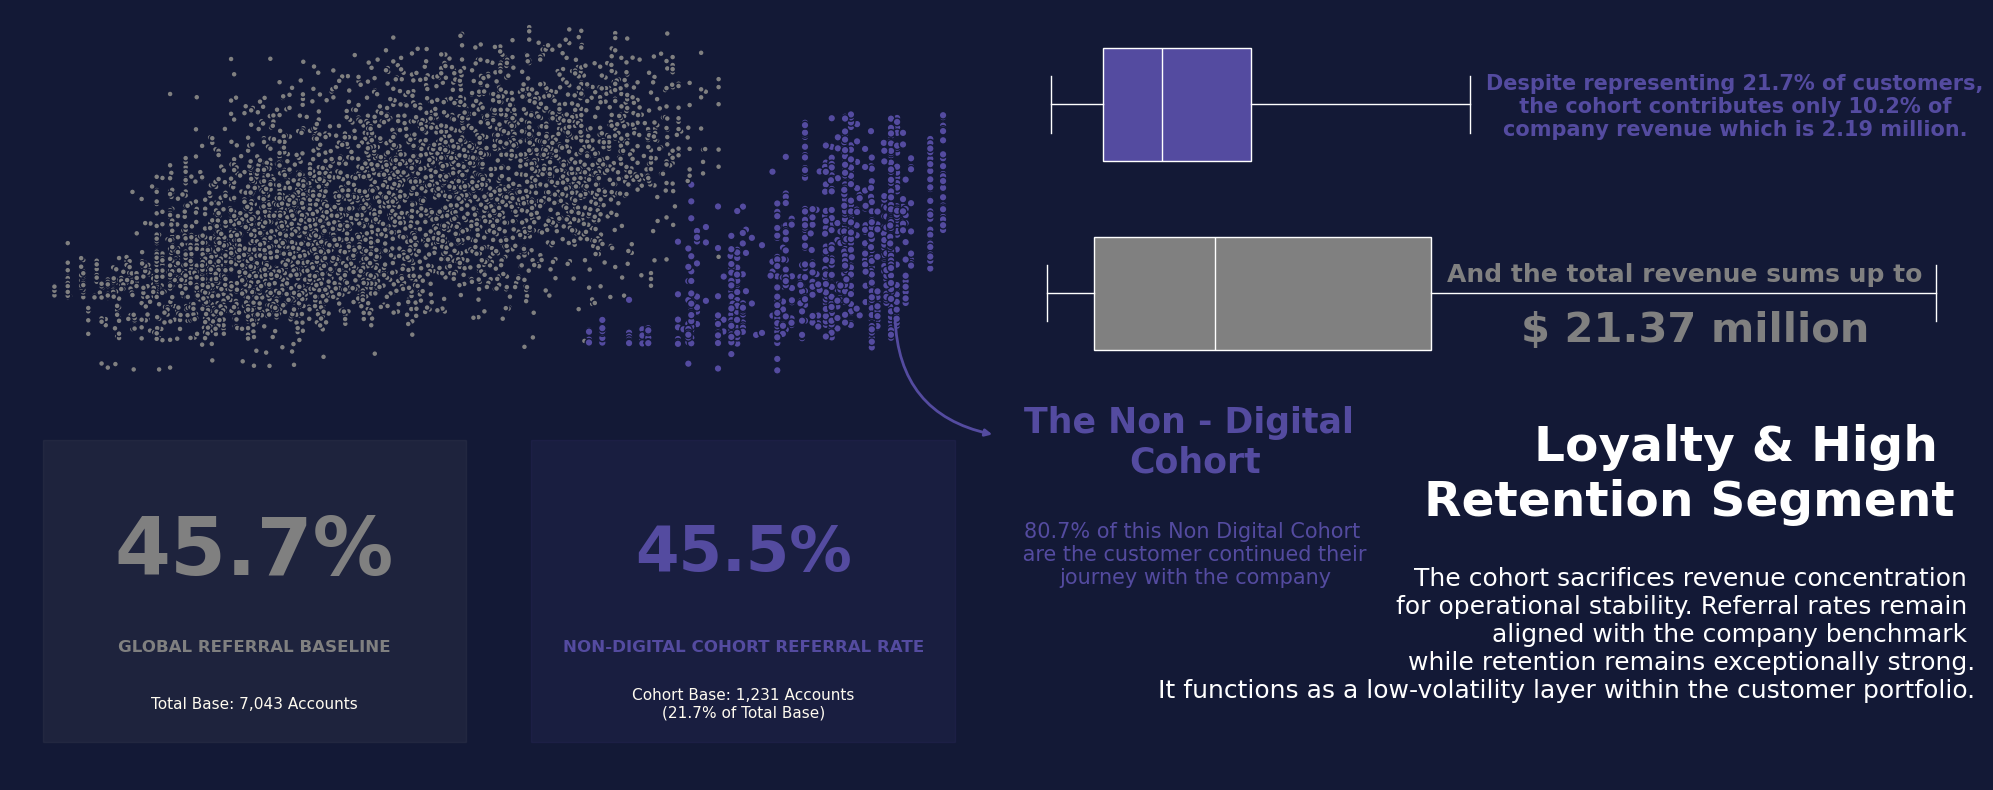

In [36]:
fig = plt.figure(figsize=(20, 8), facecolor=facecolor, dpi=100)
fig.patch.set_facecolor(facecolor)
ax1 = plt.subplot2grid((2, 6), (0, 0),colspan=3)
ax2 = plt.subplot2grid((2, 6), (0, 3),colspan=3)
ax3 = plt.subplot2grid((2, 6), (1, 0),colspan=3)
ax4 = plt.subplot2grid((2, 6), (1, 3),colspan=3)
ax1.set_facecolor(facecolor); ax2.set_facecolor(facecolor); ax3.set_facecolor(facecolor); ax4.set_facecolor(facecolor)
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_visible(False)
# ax1
# plot 1: The Global Background (Muted Grey & Faded)
ax1.scatter(prepared["NCRF"], prepared["NVF"], c=np.where(prepared["Retention_Flag"] == "Yes", stayat, "grey"), s=np.where(prepared["Retention_Flag"] == "Yes", 30, 18),edgecolor=facecolor)

# plot 3: the refferal plot
ax3.axvspan(2, 28, color="grey", alpha=0.1, ymin=0.1, ymax=0.9)
ax3.text(15, 1.2, "45.7%", color="grey", fontsize=58, fontweight="bold", ha="center", va="center")
ax3.text(15, 0.7, "GLOBAL REFERRAL BASELINE", color="grey", fontsize=12, fontweight="bold", ha="center", va="center")
ax3.text(15, 0.4, "Total Base: 7,043 Accounts", color="#fffbf0", fontsize=11, ha="center", va="center")

ax3.axvspan(32, 58, color=stayat, alpha=0.1, ymin=0.1, ymax=0.9)
ax3.text(45, 1.2, "45.5%", color=stayat, fontsize=45, fontweight="bold", ha="center", va="center")
ax3.text(45, 0.7, "NON-DIGITAL COHORT REFERRAL RATE", color=stayat, fontsize=12, fontweight="bold", ha="center", va="center")
ax3.text(45, 0.4, "Cohort Base: 1,231 Accounts\n(21.7% of Total Base)", color="#fffbf0", fontsize=11, ha="center", va="center")

ax3.set(xlim=(0, 60), ylim=(0, 2), xticks=[], yticks=[])
# ax2: the boxplot
bp = ax2.boxplot([prepared["Total Revenue"], prepared[fortress_mask]["Total Revenue"]], vert=False, patch_artist=True, widths=0.6, showfliers=False)
for element in ['whiskers', 'caps', 'medians']: plt.setp(bp[element], color='white')
for patch, color in zip(bp["boxes"], ["grey", stayat]): patch.set(facecolor=color, edgecolor='white')

# piku piku
for ax in [ax1, ax2, ax3, ax4]: ax.set_ylabel(""); ax.set_xlabel("")
for ax in [ax1, ax2,ax3,  ax4]: ax.set_xticks([]); ax.set_yticks([])
fig.text(0.98,0.4,"Loyalty & High \nRetention Segment",color="white",fontsize=35,ha="right",va="center",fontweight="bold")
# draw_arrow(fig,(0.45,0.95),(0.45,0.55),stayat,-0.4)
# fig.text(0.45,0.95,"The Non - Digital \nCohort",va="center", ha="center", color=stayat,fontsize=25,fontweight="bold")
fig.text(0.87,0.86,"Despite representing 21.7% of customers,\n the cohort contributes only 10.2% of \ncompany revenue which is 2.19 million.",va="center", ha="center", color=stayat,fontsize=15,fontweight="bold")
fig.text(0.845,0.65,"And the total revenue sums up to",va="center", ha="center", color="grey",fontsize=18,fontweight="bold")
fig.text(0.85,0.58,"$ 21.37 million",va="center", ha="center", color="grey",fontsize=30,fontweight="bold")
fig.text(
    0.99, 0.2,
    """The cohort sacrifices revenue concentration \nfor operational stability. Referral rates remain 
 aligned with the company benchmark \nwhile retention remains exceptionally strong.
It functions as a low-volatility layer within the customer portfolio.""",
    color="white",fontsize=18,ha="right",va="center")
draw_arrow(fig,(0.45,0.6),(0.5,0.45),stayat,0.4)
fig.text(0.6,0.3,"80.7% of this Non Digital Cohort \n are the customer continued their \njourney with the company",va="center", ha="center", color=stayat,fontsize=15,fontweight="regular")
fig.text(0.6,0.44,"The Non - Digital \nCohort",va="center", ha="center", color=stayat,fontsize=25,fontweight="bold")
# plt.savefig("ghost dashboard3.png", dpi=300, bbox_inches="tight", facecolor=facecolor) 
# Don't worry, the narrative isn't broken—it just shifted from a 
# "growth marketing story" to an "operational stability story." This is actually a much more powerful 
# finding for a Data Analytics Engineer because it highlights risk mitigation rather than artificial metrics.
plt.tight_layout()
plt.show()

In [37]:
prepared.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason',
       'Churn_Category', 'NVF', 'NCRF', 'Value_Tier', 'Strategic_Segment',
       'Age Group', 'Tenure in Years', 'Referral Flag', 'Dependent Flag',
       'Revenue_Tier', 'Refund_Status', 'Retention_Flag'],
      dtype='object')

In [38]:
cols = ['Premium Tech Support' , 'Internet Type', 'Online Backup', 'Device Protection Plan', 'Streaming TV', 'Streaming Music',
        'Internet Service','Online Security','Streaming Movies']
for i in cols:
    print(prepared[i].value_counts())

Premium Tech Support
No      3473
Yes     2044
None    1526
Name: count, dtype: int64
Internet Type
Fiber Optic    3035
DSL            1652
None           1526
Cable           830
Name: count, dtype: int64
Online Backup
No      3088
Yes     2429
None    1526
Name: count, dtype: int64
Device Protection Plan
No      3095
Yes     2422
None    1526
Name: count, dtype: int64
Streaming TV
No      2810
Yes     2707
None    1526
Name: count, dtype: int64
Streaming Music
No      3029
Yes     2488
None    1526
Name: count, dtype: int64
Internet Service
Yes    5517
No     1526
Name: count, dtype: int64
Online Security
No      3498
Yes     2019
None    1526
Name: count, dtype: int64
Streaming Movies
No      2785
Yes     2732
None    1526
Name: count, dtype: int64


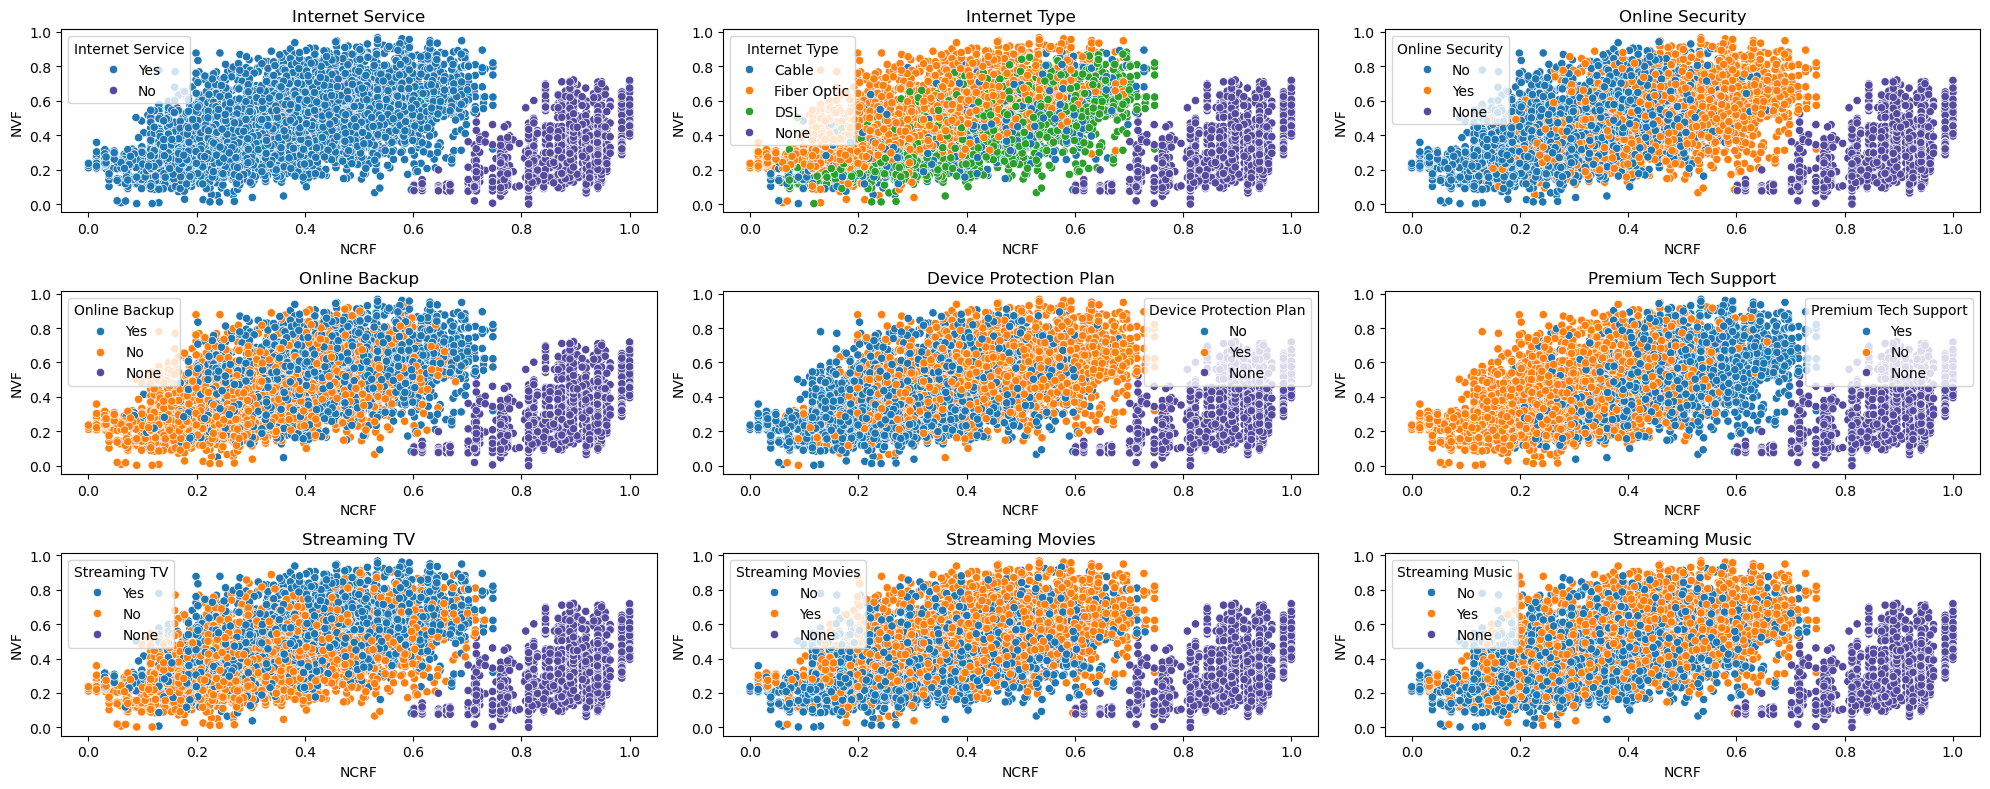

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(20, 8))

cols = [
    'Internet Service',
    'Internet Type',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music'
]

highlight = {
    'Internet Service': 'No',
    'Internet Type': 'None',
    'Online Security': 'None',
    'Online Backup': 'None',
    'Device Protection Plan': 'None',
    'Premium Tech Support': 'None',
    'Streaming TV': 'None',
    'Streaming Movies': 'None',
    'Streaming Music': 'None'
}

default = sns.color_palette()

for ax, col in zip(axes.flat, cols):
    cats = list(prepared[col].dropna().unique())
    palette = dict(zip(cats, default[:len(cats)]))
    palette[highlight[col]] = stayat
    sns.scatterplot(data=prepared, x="NCRF", y="NVF", hue=col, palette=palette, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()